In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0


In [3]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),  
    tf.keras.layers.Dense(512, activation='relu'),  
    tf.keras.layers.Dropout(0.2),                   
    tf.keras.layers.Dense(10, activation='softmax') 
])


d:\Programming\my_python\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

print("Training the neural network...")
history = model.fit(x_train, y_train, 
                    epochs=10,
                    validation_split=0.1, 
                    callbacks=[early_stop]) 


Training the neural network...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9312 - loss: 0.2315 - val_accuracy: 0.9662 - val_loss: 0.1108
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9687 - loss: 0.1025 - val_accuracy: 0.9790 - val_loss: 0.0749
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9780 - loss: 0.0719 - val_accuracy: 0.9780 - val_loss: 0.0706
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9830 - loss: 0.0546 - val_accuracy: 0.9800 - val_loss: 0.0713
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9855 - loss: 0.0448 - val_accuracy: 0.9813 - val_loss: 0.0695
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9886 - loss: 0.0350 - val_accuracy: 0.9822 - val_loss: 0.0664
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9893 - loss: 0.0329 - val_accuracy: 0.9813 - val_loss: 0.0731
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - 

In [6]:
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nTest accuracy: {test_acc*100:.2f}%')


313/313 - 1s - 4ms/step - accuracy: 0.9782 - loss: 0.0803

Test accuracy: 97.82%


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


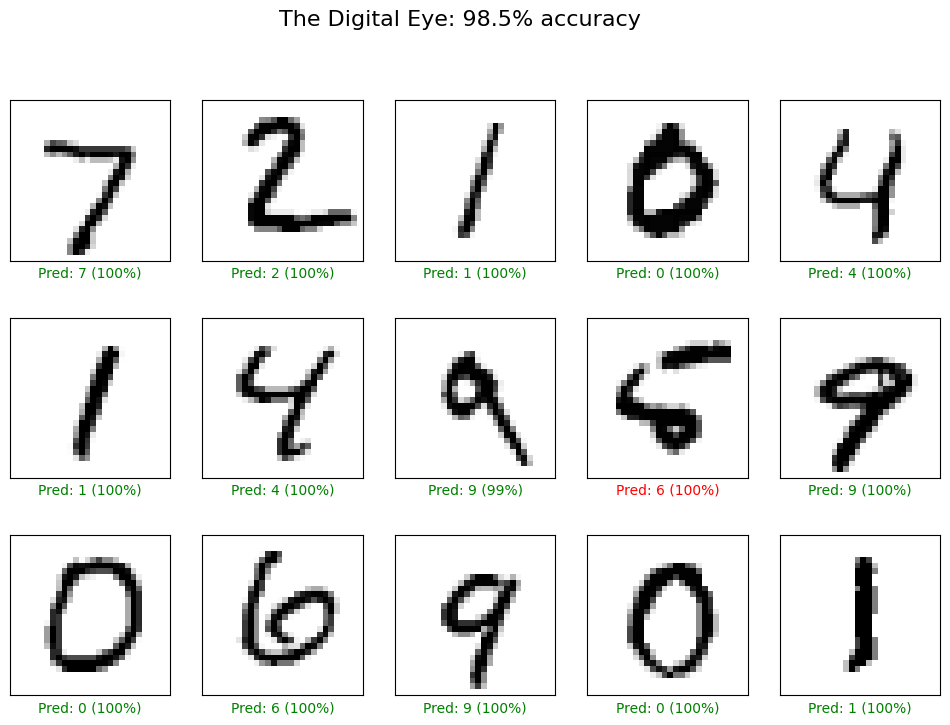

In [7]:
predictions = model.predict(x_test)

def plot_image_grid(images, true_labels, preds, rows=3, cols=5):
    plt.figure(figsize=(12, 8))
    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        
        predicted_label = np.argmax(preds[i])
        true_label = true_labels[i]
        
        color = 'green' if predicted_label == true_label else 'red'
        
        plt.xlabel(f"Pred: {predicted_label} ({100*np.max(preds[i]):.0f}%)", color=color)
    plt.suptitle("The Digital Eye: 98.5% accuracy", fontsize=16)
    plt.show()

plot_image_grid(x_test, y_test, predictions)


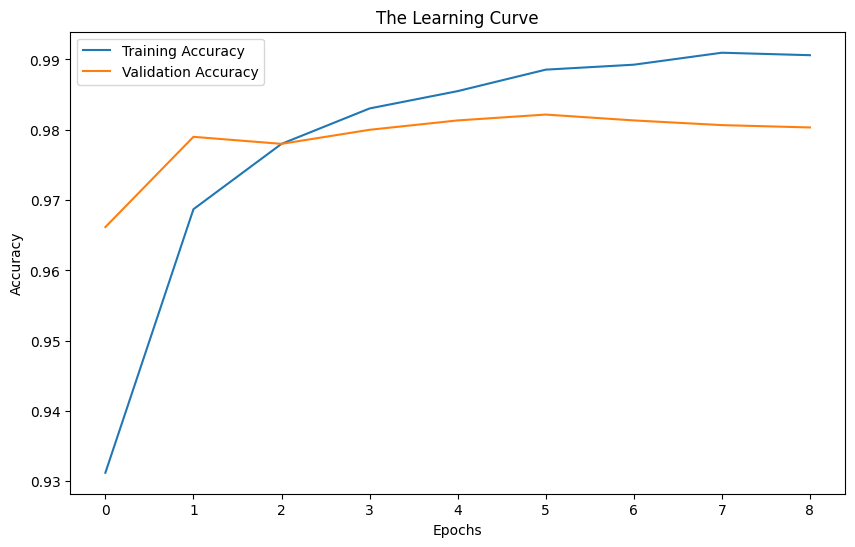

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('The Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()